<a href="https://colab.research.google.com/github/mariazafran/RPCI-Herding-Measure/blob/main/RPIC_CSSD_CSAD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [ ]:
tickers = [
    'HSBA.L','BP.L','SHEL.L','AZN.L','ULVR.L','RIO.L','GSK.L','BARC.L',
    'LLOY.L','DGE.L','REL.L','PRU.L','NG.L','LSEG.L','GLEN.L','BT-A.L',
    'BATS.L','NWG.L','EXPN.L','SMIN.L','AAL.L','CNA.L','IMB.L','MNDI.L',
    'SGE.L','STAN.L','RR.L','CRH.L','KGF.L','FRES.L','EDV.L','WEIR.L',
    'ABF.L','ADM.L','AUTO.L','BDEV.L','BEZ.L','BNZL.L','BRBY.L','CCH.L',
    'CTEC.L','DCC.L','ENT.L','FLTR.L','HLMA.L','HIK.L','HSX.L','IAG.L',
    'IHG.L','INF.L','ITRK.L','JD.L','JET2.L','JMAT.L','LAND.L','LGEN.L',
    'MKS.L','MRW.L','NGHT.L','NXT.L','OCDO.L','PSN.L','PNN.L','PSON.L',
    'RTO.L','SDR.L','SGRO.L','SBRY.L','SMT.L','SVT.L','TSCO.L','TW.L',
    'UU.L','VOD.L','WTB.L','WPP.L','SPX.L','DRX.L','HWDN.L','PHNX.L',
    'AV.L','III.L','DPLM.L','ASHM.L','OSB.L','SAFE.L'
]

data = yf.download(tickers, start='2018-01-01')

prices = data['Close']

/tmp/ipykernel_2563/2634621913.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start='2018-01-01')
[**********            21%                       ]  18 of 86 completedERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: PHNX.L"}}}
[*********************100%***********************]  86 of 86 completed
ERROR:yfinance:
4 Failed downloads:
ERROR:yfinance:['PHNX.L', 'MRW.L', 'BDEV.L', 'NGHT.L']: YFTzMissingError('possibly delisted; no timezone found')


In [ ]:
prices = prices.dropna(axis=1)

In [ ]:
returns = np.log(prices / prices.shift(1))
returns = returns.dropna()

In [ ]:
Rm = returns.mean(axis=1)

In [ ]:
csad = (returns.sub(Rm, axis=0).abs()).mean(axis=1)

In [ ]:
abs_Rm = np.abs(Rm)
Rm_sq = Rm**2

X_csad = pd.DataFrame({
    'abs_Rm': abs_Rm,
    'Rm_sq': Rm_sq
})

X_csad = sm.add_constant(X_csad)

In [ ]:
model_csad = sm.OLS(csad, X_csad).fit(cov_type='HC3')
print(model_csad.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.299
Model:                            OLS   Adj. R-squared:                  0.299
Method:                 Least Squares   F-statistic:                     95.62
Date:                Wed, 03 Jun 2026   Prob (F-statistic):           1.74e-40
Time:                        16:52:36   Log-Likelihood:                 8836.0
No. Observations:                2125   AIC:                        -1.767e+04
Df Residuals:                    2122   BIC:                        -1.765e+04
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0091      0.001     17.772      0.0

In [ ]:
cssd = np.sqrt(((returns.sub(Rm, axis=0))**2).mean(axis=1))

In [ ]:
upper = Rm.quantile(0.99)
lower = Rm.quantile(0.01)

D_up = (Rm > upper).astype(int)
D_down = (Rm < lower).astype(int)

In [ ]:
X_cssd = pd.DataFrame({
    'D_up': D_up,
    'D_down': D_down
})

X_cssd = sm.add_constant(X_cssd)

model_cssd = sm.OLS(cssd, X_cssd).fit(cov_type='HC3')
print(model_cssd.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.153
Model:                            OLS   Adj. R-squared:                  0.152
Method:                 Least Squares   F-statistic:                     30.73
Date:                Wed, 03 Jun 2026   Prob (F-statistic):           6.95e-14
Time:                        16:52:43   Log-Likelihood:                 7831.5
No. Observations:                2125   AIC:                        -1.566e+04
Df Residuals:                    2122   BIC:                        -1.564e+04
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0155      0.000    122.822      0.0

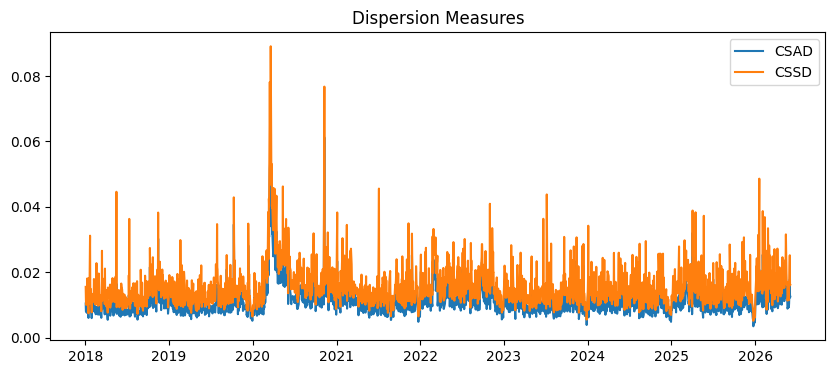

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(csad, label='CSAD')
plt.plot(cssd, label='CSSD')
plt.legend()
plt.title("Dispersion Measures")
plt.show()

In [ ]:
# Rolling window (you used 20 before — keep consistent)
k = 20

performance = returns.rolling(k).mean()
performance = performance.dropna()

In [ ]:
gap = performance.sub(performance.mean(axis=1), axis=0)

In [ ]:
delta_p = performance.diff().shift(-1)

In [ ]:
gap = gap.iloc[:-1]
delta_p = delta_p.iloc[:-1]

In [ ]:
gap = gap.dropna()
delta_p = delta_p.dropna()

In [ ]:
gap_std = gap.std()
delta_std = delta_p.std()

# avoid division by zero
gap_std[gap_std == 0] = 1
delta_std[delta_std == 0] = 1

gap_norm = (gap - gap.mean()) / gap_std
delta_norm = (delta_p - delta_p.mean()) / delta_std

In [ ]:
rpci = (-gap_norm * delta_norm).mean(axis=1)
rpci = rpci.dropna()

In [ ]:
rpci = (rpci - rpci.mean()) / rpci.std()

In [ ]:
rpci_smooth = rpci.rolling(50).mean()

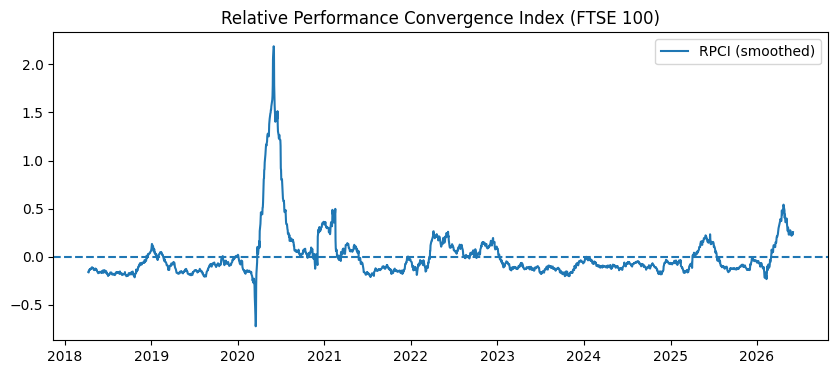

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(rpci_smooth, label='RPCI (smoothed)')
plt.axhline(0, linestyle='--')
plt.legend()
plt.title("Relative Performance Convergence Index (FTSE 100)")
plt.show()

In [ ]:
mean_rpc = rpci.mean()
t_stat_rpc = mean_rpc / (rpci.std() / np.sqrt(len(rpci)))

print("Full Sample Mean RPCI:", mean_rpc)
print("Full Sample t-stat:", t_stat_rpc)

Full Sample Mean RPCI: 2.3628499526464138e-17
Full Sample t-stat: 1.0840821503376968e-15


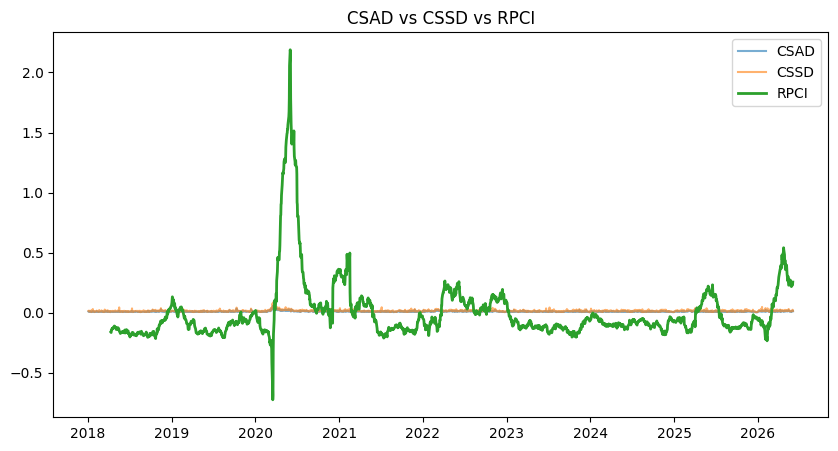

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(csad, label='CSAD', alpha=0.6)
plt.plot(cssd, label='CSSD', alpha=0.6)
plt.plot(rpci_smooth, label='RPCI', linewidth=2)

plt.legend()
plt.title("CSAD vs CSSD vs RPCI")
plt.show()

In [ ]:
print("\n================ CURRENT MODEL RESULTS =================\n")

# -------- CSAD --------
print("CSAD MODEL")
print("Beta (Rm_sq):", model_csad.params['Rm_sq'])
print("t-stat:", model_csad.tvalues['Rm_sq'])
print("p-value:", model_csad.pvalues['Rm_sq'])

print("\n------------------------------------------------------\n")

# -------- CSSD --------
print("CSSD MODEL")
print("D_up Coeff:", model_cssd.params['D_up'])
print("D_up t-stat:", model_cssd.tvalues['D_up'])
print("D_down Coeff:", model_cssd.params['D_down'])
print("D_down t-stat:", model_cssd.tvalues['D_down'])

print("\n------------------------------------------------------\n")

# -------- RPCI --------
print("RPCI MODEL (Full Sample)")
print("Mean RPCI:", mean_rpc)
print("t-stat RPCI:", t_stat_rpc)


================ CURRENT MODEL RESULTS =================

CSAD MODEL
Beta (Rm_sq): 0.854577787478111
t-stat: 0.1976983939375971
p-value: 0.8432810463669531

------------------------------------------------------

CSSD MODEL
D_up Coeff: 0.018336692533056736
D_up t-stat: 6.014089186918397
D_down Coeff: 0.017911450325570413
D_down t-stat: 5.038502553836694

------------------------------------------------------

RPCI MODEL (Full Sample)
Mean RPCI: 2.3628499526464138e-17
t-stat RPCI: 1.0840821503376968e-15


In [ ]:

start = '2020-02-01'
end = '2021-01-31'

In [ ]:
# Subset
csad_crisis = csad[start:end]
Rm_crisis = Rm[start:end]

# Variables
abs_Rm_crisis = np.abs(Rm_crisis)
Rm_sq_crisis = Rm_crisis**2

# Regression
X_csad_crisis = pd.DataFrame({
    'abs_Rm': abs_Rm_crisis,
    'Rm_sq': Rm_sq_crisis
})

X_csad_crisis = sm.add_constant(X_csad_crisis)

model_csad_crisis = sm.OLS(csad_crisis, X_csad_crisis).fit(cov_type='HC3')

print("\nCSAD CRISIS RESULTS")
print("Beta (Rm_sq):", model_csad_crisis.params['Rm_sq'])
print("t-stat:", model_csad_crisis.tvalues['Rm_sq'])
print("p-value:", model_csad_crisis.pvalues['Rm_sq'])


CSAD CRISIS RESULTS
Beta (Rm_sq): -1.105376101412457
t-stat: -0.23978339088782266
p-value: 0.8104981835497329


In [ ]:
# Subset
cssd_crisis = cssd[start:end]
Rm_crisis = Rm[start:end]

# Extreme thresholds
upper = Rm_crisis.quantile(0.99)
lower = Rm_crisis.quantile(0.01)

# Dummies
D_up_crisis = (Rm_crisis > upper).astype(int)
D_down_crisis = (Rm_crisis < lower).astype(int)

# Regression
X_cssd_crisis = pd.DataFrame({
    'D_up': D_up_crisis,
    'D_down': D_down_crisis
})

X_cssd_crisis = sm.add_constant(X_cssd_crisis)

model_cssd_crisis = sm.OLS(cssd_crisis, X_cssd_crisis).fit(cov_type='HC3')

print("\nCSSD CRISIS RESULTS")
print("D_up Coeff:", model_cssd_crisis.params['D_up'])
print("D_up t-stat:", model_cssd_crisis.tvalues['D_up'])
print("D_down Coeff:", model_cssd_crisis.params['D_down'])
print("D_down t-stat:", model_cssd_crisis.tvalues['D_down'])


CSSD CRISIS RESULTS
D_up Coeff: 0.039829295752041645
D_up t-stat: 4.053414489765044
D_down Coeff: 0.032100258426539414
D_down t-stat: 2.073834134589671


In [ ]:
crisis = rpci[start:end]

mean_crisis = crisis.mean()
t_stat_crisis = mean_crisis / (crisis.std() / np.sqrt(len(crisis)))

print("\nRPCI CRISIS RESULTS")
print("Mean RPCI:", mean_crisis)
print("t-stat:", t_stat_crisis)


RPCI CRISIS RESULTS
Mean RPCI: 0.41790921837167727
t-stat: 2.755139740101978


In [ ]:
crisis_results = pd.DataFrame({
    "Model": ["CSAD", "CSSD (Up)", "CSSD (Down)", "RPCI"],
    "Crisis Coefficient": [
        model_csad_crisis.params['Rm_sq'],
        model_cssd_crisis.params['D_up'],
        model_cssd_crisis.params['D_down'],
        mean_crisis
    ],
    "t-stat": [
        model_csad_crisis.tvalues['Rm_sq'],
        model_cssd_crisis.tvalues['D_up'],
        model_cssd_crisis.tvalues['D_down'],
        t_stat_crisis
    ]
})

print("\n=== CRISIS COMPARISON ===")
print(crisis_results)


=== CRISIS COMPARISON ===
         Model  Crisis Coefficient    t-stat
0         CSAD           -1.105376 -0.239783
1    CSSD (Up)            0.039829  4.053414
2  CSSD (Down)            0.032100  2.073834
3         RPCI            0.417909  2.755140
